In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [5]:
!kaggle datasets download -d agrigorev/clothing-dataset-full

Dataset URL: https://www.kaggle.com/datasets/agrigorev/clothing-dataset-full
License(s): CC0-1.0
100% 6.50G/6.50G [01:24<00:00, 82.2MB/s]



In [6]:
import zipfile
zip_ref = zipfile.ZipFile('/content/clothing-dataset-full.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [7]:
#here we read the csv file that we have imported from the kaggle document
df = pd.read_csv('images.csv')
df.head()

,image,sender_id,label,kids
0,4285fab0-751a-4b74-8e9b-43af05deee22,124,Not sure,False
1,ea7b6656-3f84-4eb3-9099-23e623fc1018,148,T-Shirt,False
2,00627a3f-0477-401c-95eb-92642cbe078d,94,Not sure,False
3,ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa,43,T-Shirt,False
4,3b86d877-2b9e-4c8b-a6a2-1d87513309d0,189,Shoes,False


In [8]:
#we will join the image name with .jpg file form
df['image'] = df['image']+'.jpg'

In [9]:
#after editing the csv dataframe file we will then
data = df[['image', 'label']]
data.head()

,image,label
0,4285fab0-751a-4b74-8e9b-43af05deee22.jpg,Not sure
1,ea7b6656-3f84-4eb3-9099-23e623fc1018.jpg,T-Shirt
2,00627a3f-0477-401c-95eb-92642cbe078d.jpg,Not sure
3,ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa.jpg,T-Shirt
4,3b86d877-2b9e-4c8b-a6a2-1d87513309d0.jpg,Shoes


In [10]:
#here now we will unzip the file folder that we have imported from
#import zipfile

#zipFilePath = 'images_compressed.zip'
#extractedPath = 'images/'

#Unzip the file
#with zipfile.ZipFile(zipFilePath, 'r') as zip_ref:
#    zip_ref.extractall(extractedPath)

#print("Extraction completed successfully!")

In [11]:
extractedPath = '/content/images_compressed/'

In [12]:
import PIL
from pathlib import Path
from PIL import UnidentifiedImageError

path = Path(extractedPath).rglob("*.jpg")
for img_p in path:
    try:
        img = PIL.Image.open(img_p)
    except PIL.UnidentifiedImageError:
            print(img_p)



/content/images_compressed/d028580f-9a98-4fb5-a6c9-5dc362ad3f09.jpg
/content/images_compressed/b72ed5cd-9f5f-49a7-b12e-63a078212a17.jpg
/content/images_compressed/040d73b7-21b5-4cf2-84fc-e1a80231b202.jpg
/content/images_compressed/1d0129a1-f29a-4a3f-b103-f651176183eb.jpg
/content/images_compressed/c60e486d-10ed-4f64-abab-5bb698c736dd.jpg
/content/images_compressed/784d67d4-b95e-4abb-baf7-8024f18dc3c8.jpg


here the above code you can see that I am checking whether there is any currupted file or not, by the help of this I will be easier for the model to not train with the corrupted images

In [13]:
remove_images = ['040d73b7-21b5-4cf2-84fc-e1a80231b202.jpg', '1d0129a1-f29a-4a3f-b103-f651176183eb.jpg', '784d67d4-b95e-4abb-baf7-8024f18dc3c8.jpg', 'b72ed5cd-9f5f-49a7-b12e-63a078212a17.jpg','c60e486d-10ed-4f64-abab-5bb698c736dd.jpg','d028580f-9a98-4fb5-a6c9-5dc362ad3f09.jpg']

In [14]:
''' here we first check how many datas did we removed'''
data.shape

(5403, 2)

In [15]:
'''here we will delete those corrupted files that are present in the data'''
data = data.drop(data[data['image'].isin(remove_images)].index, axis=0)
data.shape

(5398, 2)

In [16]:
'''add the full path'''
data['fullpath'] = extractedPath + data['image']

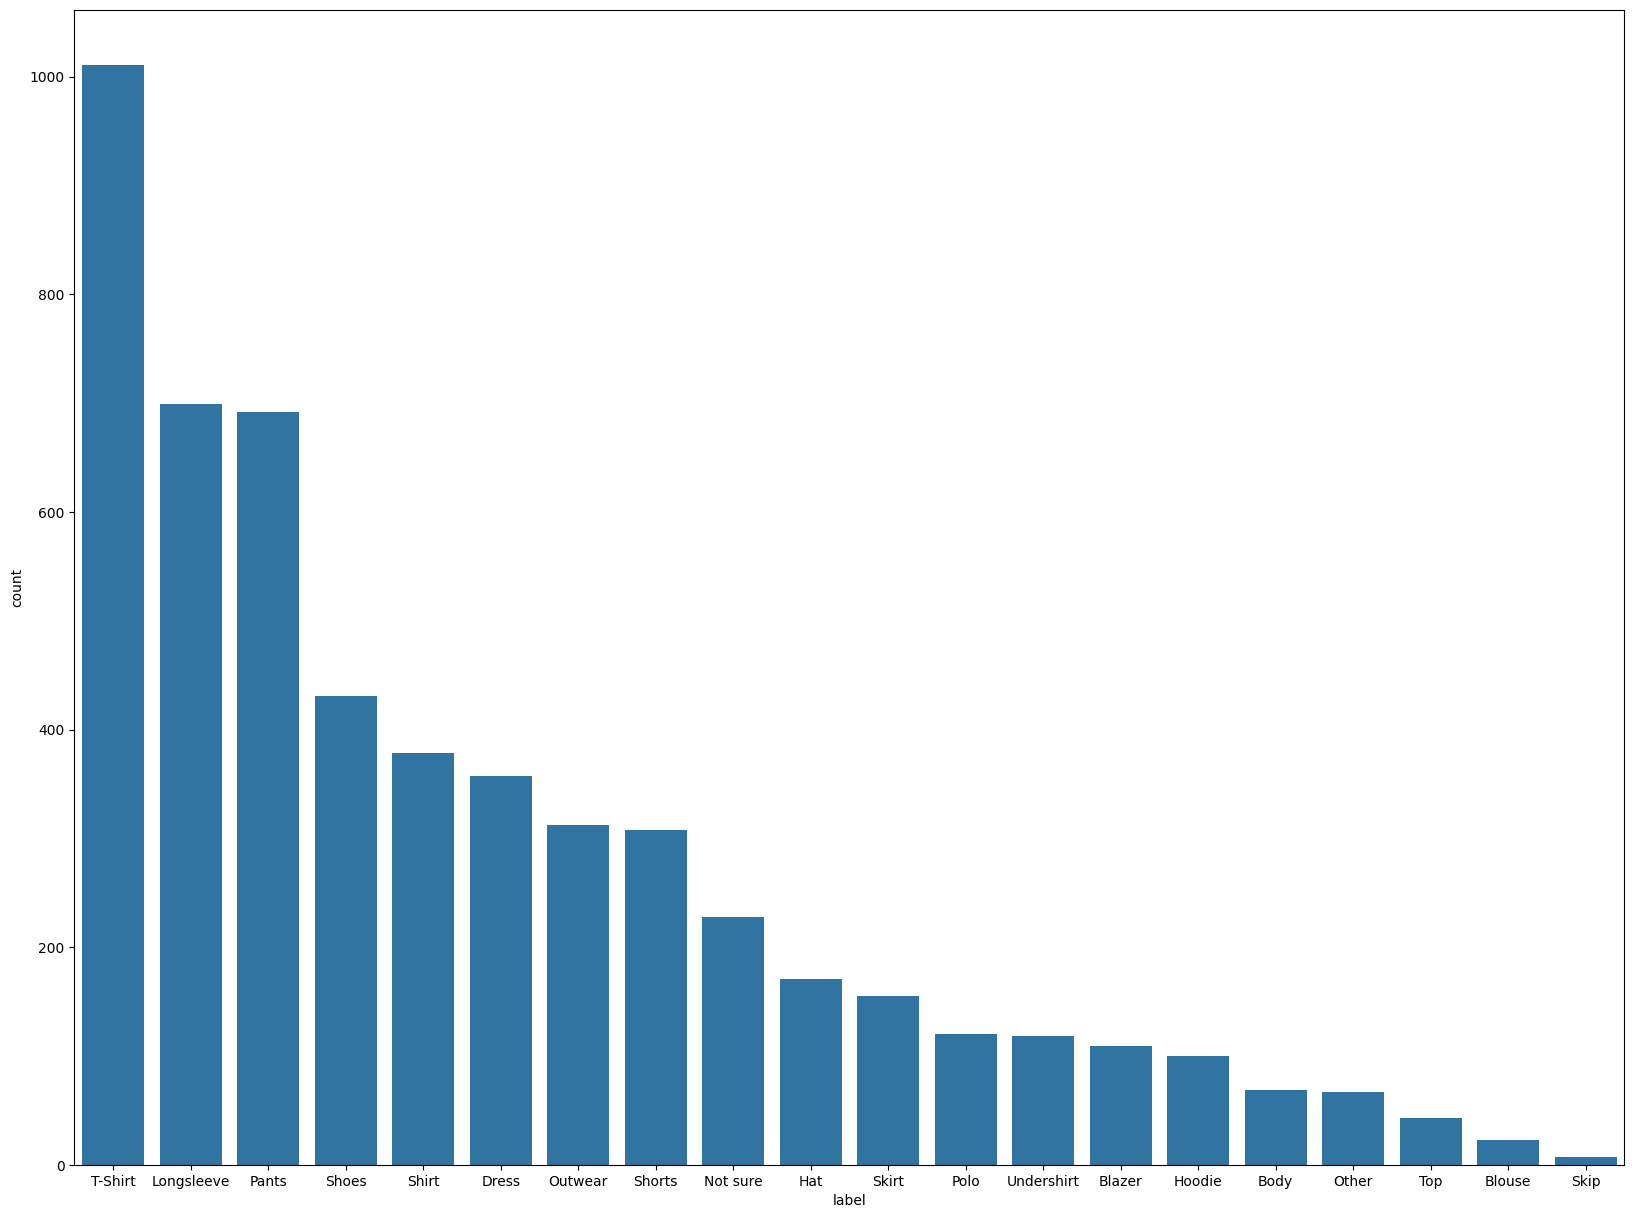

In [17]:
'''here we will first check whether there is imbalance in the data or not'''
plt.figure(figsize=(20,15))
fig = sns.barplot(data['label'].value_counts())
plt.show()

In [18]:
data['label'].unique()

array(['Not sure', 'T-Shirt', 'Shoes', 'Shorts', 'Shirt', 'Pants',
       'Skirt', 'Other', 'Top', 'Outwear', 'Dress', 'Body', 'Longsleeve',
       'Undershirt', 'Hat', 'Polo', 'Blouse', 'Hoodie', 'Skip', 'Blazer'],
      dtype=object)

In [19]:
'''here we will now remove those labels from the data that no meaning as you can see above like Other, Skip'''
labels_to_remove = ['Not sure','Skip','Other']

In [20]:
data = data[~data['label'].isin(labels_to_remove)]
data.shape[0]

5096

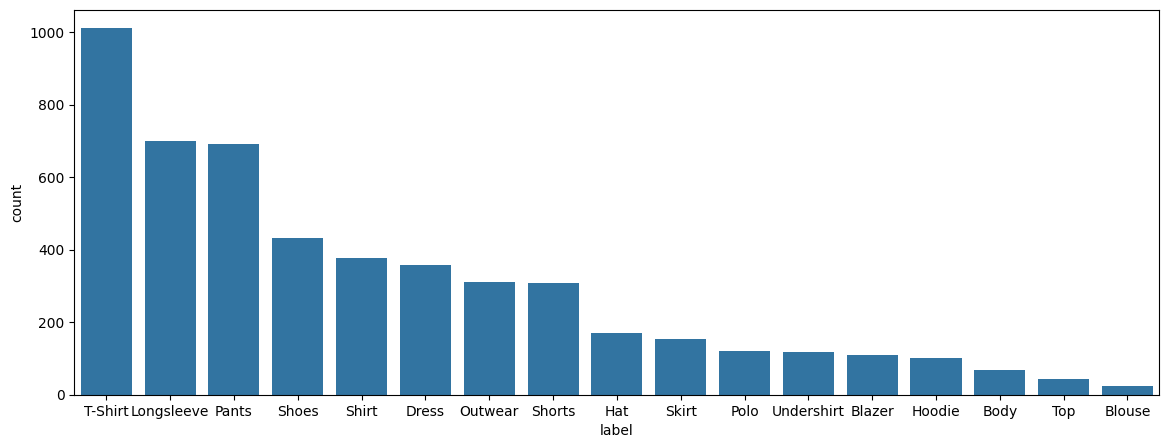

In [21]:
'''Now let's check it again whether it has been removed or not'''
plt.figure(figsize=(14,5))
fig = sns.barplot(data['label'].value_counts())
plt.show()

#### Spliting the data for making training and validation data

In [22]:
from sklearn.model_selection import train_test_split
train_df, validation_df = train_test_split(data, test_size=0.2, random_state=42, stratify=data['label'])

In [23]:
'''Save the split dataframes to temporary files'''
#train_df.to_csv('train_df.csv',index=False)
#validation_df.to_csv('valid_df.csv', index=False)

'Save the split dataframes to temporary files'

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
'''Create ImageDataGenerator for training(with augumentation)'''
'''for training augumentation'''
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

# Create ImageDataGenerator for validation (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)


In [25]:
IMG_SIZE = (256,256)
BATCH_SIZE = 32
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='fullpath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset = 'training',
    seed = 42
)


Found 4076 validated image filenames belonging to 17 classes.


In [26]:
val_generator = val_datagen.flow_from_dataframe(
    dataframe=validation_df,
    x_col='fullpath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    seed = 42
)


Found 1020 validated image filenames belonging to 17 classes.


In [27]:
print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(validation_df)}")
print(f"Classes: {train_generator.class_indices}")


Training samples: 4076
Validation samples: 1020
Classes: {'Blazer': 0, 'Blouse': 1, 'Body': 2, 'Dress': 3, 'Hat': 4, 'Hoodie': 5, 'Longsleeve': 6, 'Outwear': 7, 'Pants': 8, 'Polo': 9, 'Shirt': 10, 'Shoes': 11, 'Shorts': 12, 'Skirt': 13, 'T-Shirt': 14, 'Top': 15, 'Undershirt': 16}


In [28]:
num_classes = len(train_df['label'].unique())
num_classes

17

In [ ]:
#Build model
model = Sequential([
    Conv2D(32, activation= 'relu', padding='same', kernel_size=(3,3), input_shape=(*IMG_SIZE, 3)),
    MaxPooling2D((2,2)),

    Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(128, kernel_size=(3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(64, activation='relu'),

    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,947,793 (49.39 MB)

 Trainable params: 12,947,793 (49.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history =  model.fit(train_generator, epochs=10, validation_data=val_generator)

Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 70s 486ms/step - accuracy: 0.1923 - loss: 2.5685 - val_accuracy: 0.1971 - val_loss: 2.4474
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 57s 445ms/step - accuracy: 0.2112 - loss: 2.4298 - val_accuracy: 0.2716 - val_loss: 2.3921
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 58s 453ms/step - accuracy: 0.2549 - loss: 2.3568 - val_accuracy: 0.3176 - val_loss: 2.2289
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 57s 447ms/step - accuracy: 0.2853 - loss: 2.2774 - val_accuracy: 0.3559 - val_loss: 2.1183
Epoch 5/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 57s 443ms/step - accuracy: 0.3315 - loss: 2.1740 - val_accuracy: 0.4069 - val_loss: 2.0044
Epoch 6/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 82s 441ms/step - accuracy: 0.3621 - loss: 2.0986 - val_accuracy: 0.4480 - val_loss: 1.8818
Epoch 7/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 57s 447ms/step - accuracy: 0.3854 - loss: 2.0332 - val_accuracy: 0.4294 - val_loss: 1.8811
Epoch 8/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 57s 442ms/step - accuracy: 0.3876 - loss: 1

here we could see that the above model has perform good from my POV, but we have to improve it more like adding droupout and see

In [ ]:
model_01 = Sequential([
    Conv2D(32, activation='relu', input_shape=(*IMG_SIZE, 3), kernel_size=(3,3), padding='valid'),
    MaxPooling2D((2,2), padding='valid'),

    Conv2D(64, kernel_size=(3,3), activation='relu', padding='valid'),
    MaxPooling2D((2,2), padding='valid'),

    Conv2D(128, kernel_size=(3,3), activation='relu', padding='valid'),
    MaxPooling2D((2,2), padding='valid'),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

In [ ]:
model_01.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_01.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 17)             │           561 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,179,857 (42.65 MB)

 Trainable params: 11,179,857 (42.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_01 = model_01.fit(train_generator, epochs=10, validation_data=val_generator)

Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 73s 497ms/step - accuracy: 0.1170 - loss: 2.7233 - val_accuracy: 0.1980 - val_loss: 2.5233
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 57s 442ms/step - accuracy: 0.1727 - loss: 2.5753 - val_accuracy: 0.1980 - val_loss: 2.4844
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 57s 442ms/step - accuracy: 0.1855 - loss: 2.5337 - val_accuracy: 0.1980 - val_loss: 2.5234
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 58s 454ms/step - accuracy: 0.1852 - loss: 2.5165 - val_accuracy: 0.1980 - val_loss: 2.5033
Epoch 5/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 58s 455ms/step - accuracy: 0.1955 - loss: 2.5019 - val_accuracy: 0.1980 - val_loss: 2.4760
Epoch 6/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 59s 462ms/step - accuracy: 0.1928 - loss: 2.4987 - val_accuracy: 0.1980 - val_loss: 2.4777
Epoch 7/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 59s 462ms/step - accuracy: 0.1950 - loss: 2.4924 - val_accuracy: 0.1980 - val_loss: 2.4787
Epoch 8/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 60s 468ms/step - accuracy: 0.1963 - loss: 2

In [ ]:
#here in the above we could see that the model is not giving good result because I gave an extra dense layer with 32 nodes which is making it overfitted so go back in normal and add the dropout function in it
model_03 = Sequential([
    Conv2D(32, activation= 'relu', padding='same', kernel_size=(3,3), input_shape=(*IMG_SIZE, 3)),
    MaxPooling2D((2,2)),

    Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(128, kernel_size=(3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_03.compile(optimizer='adam', loss=['categorical_crossentropy'], metrics=['accuracy'])
model_03.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,947,793 (49.39 MB)

 Trainable params: 12,947,793 (49.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_03 = model_03.fit(train_generator, epochs=10, validation_data=val_generator)

Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 70s 502ms/step - accuracy: 0.1759 - loss: 2.6121 - val_accuracy: 0.1980 - val_loss: 2.5009
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 59s 463ms/step - accuracy: 0.1889 - loss: 2.5147 - val_accuracy: 0.2255 - val_loss: 2.5066
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 64s 504ms/step - accuracy: 0.1946 - loss: 2.4863 - val_accuracy: 0.2539 - val_loss: 2.3612
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 67s 520ms/step - accuracy: 0.2174 - loss: 2.4407 - val_accuracy: 0.2627 - val_loss: 2.3154
Epoch 5/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 65s 508ms/step - accuracy: 0.2390 - loss: 2.3992 - val_accuracy: 0.3010 - val_loss: 2.2302
Epoch 6/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 60s 466ms/step - accuracy: 0.2758 - loss: 2.3150 - val_accuracy: 0.3382 - val_loss: 2.1238
Epoch 7/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 63s 486ms/step - accuracy: 0.2981 - loss: 2.2653 - val_accuracy: 0.3794 - val_loss: 2.0521
Epoch 8/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 66s 518ms/step - accuracy: 0.3160 - loss: 2

let's add padding = same in maxpooling2d function

In [ ]:
model_04 = Sequential([
    Conv2D(32, activation= 'relu', padding='same', kernel_size=(3,3), input_shape=(*IMG_SIZE, 3)),
    MaxPooling2D((2,2), padding='same'),

    Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2), padding= 'same'),

    Conv2D(128, kernel_size=(3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2), padding='same'),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_04.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_04.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,947,793 (49.39 MB)

 Trainable params: 12,947,793 (49.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_04 = model_04.fit(train_generator, epochs=10, validation_data=val_generator)

Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 71s 522ms/step - accuracy: 0.1641 - loss: 2.6219 - val_accuracy: 0.1980 - val_loss: 2.4622
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 63s 493ms/step - accuracy: 0.1833 - loss: 2.5130 - val_accuracy: 0.1980 - val_loss: 2.4583
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 63s 491ms/step - accuracy: 0.1995 - loss: 2.4900 - val_accuracy: 0.2088 - val_loss: 2.4025
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 64s 499ms/step - accuracy: 0.2125 - loss: 2.4443 - val_accuracy: 0.2539 - val_loss: 2.3784
Epoch 5/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 60s 471ms/step - accuracy: 0.2402 - loss: 2.4140 - val_accuracy: 0.2922 - val_loss: 2.2891
Epoch 6/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 63s 494ms/step - accuracy: 0.2610 - loss: 2.3653 - val_accuracy: 0.2980 - val_loss: 2.2509
Epoch 7/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 63s 489ms/step - accuracy: 0.2814 - loss: 2.3125 - val_accuracy: 0.3500 - val_loss: 2.1505
Epoch 8/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 61s 476ms/step - accuracy: 0.3081 - loss: 2

let's try using double conv2d to have more kernel size of it

In [ ]:
model_05 = Sequential([
    Conv2D(32, activation= 'relu', padding='same', kernel_size=(3,3), input_shape=(*IMG_SIZE, 3)),
    Conv2D(32, activation= 'relu', padding='same', kernel_size=(3,3)),
    MaxPooling2D((2,2), padding='same'),

    Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),
    Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2), padding= 'same'),

    Conv2D(128, kernel_size=(3,3), activation='relu', padding='same'),
    Conv2D(128, kernel_size=(3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2), padding='same'),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_05.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_05.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,141,553 (50.13 MB)

 Trainable params: 13,141,553 (50.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_05 = model_05.fit(train_generator, epochs=50, validation_data=val_generator)

Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 92s 576ms/step - accuracy: 0.1676 - loss: 2.5885 - val_accuracy: 0.1980 - val_loss: 2.4904
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 58s 450ms/step - accuracy: 0.1798 - loss: 2.5289 - val_accuracy: 0.1980 - val_loss: 2.4777
Epoch 3/50
124/128 ━━━━━━━━━━━━━━━━━━━━ 1s 440ms/step - accuracy: 0.1789 - loss: 2.5220

KeyboardInterrupt: 

let's try using kernel initialization with sequential model

In [ ]:
from tensorflow.keras import initializers

initializer = tf.keras.initializers.HeUniform()

model_06 = Sequential([
    Conv2D(32, activation= 'relu', padding='same', kernel_size=(3,3), kernel_initializer='he_uniform', input_shape=(*IMG_SIZE, 3)),
    Conv2D(32, activation= 'relu', padding='same',kernel_initializer='he_uniform' ,kernel_size=(3,3)),
    MaxPooling2D((2,2), padding='valid'),

    Conv2D(64, kernel_size=(3,3), activation='relu',kernel_initializer='he_uniform', padding='same'),
    Conv2D(64, kernel_size=(3,3), activation='relu',kernel_initializer='he_uniform', padding='same'),
    MaxPooling2D((2,2), padding= 'valid'),

    Conv2D(128, kernel_size=(3,3), activation='relu', kernel_initializer='he_uniform', padding='same'),
    Conv2D(128, kernel_size=(3,3), activation='relu', kernel_initializer='he_uniform', padding='same'),
    MaxPooling2D((2,2), padding='valid'),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

In [ ]:
model_06.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_06.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,141,553 (50.13 MB)

 Trainable params: 13,141,553 (50.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_06 = model_06.fit(train_generator, epochs=50, validation_data=val_generator)

Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 74s 534ms/step - accuracy: 0.1570 - loss: 3.0982 - val_accuracy: 0.1980 - val_loss: 2.4879
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 63s 494ms/step - accuracy: 0.1791 - loss: 2.5410 - val_accuracy: 0.1980 - val_loss: 2.4921
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 69s 536ms/step - accuracy: 0.1879 - loss: 2.5199 - val_accuracy: 0.1980 - val_loss: 2.4742
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 64s 496ms/step - accuracy: 0.1928 - loss: 2.4995 - val_accuracy: 0.1980 - val_loss: 2.4620
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 60s 471ms/step - accuracy: 0.1931 - loss: 2.4974 - val_accuracy: 0.2098 - val_loss: 2.4397
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 63s 488ms/step - accuracy: 0.2122 - loss: 2.4734 - val_accuracy: 0.2382 - val_loss: 2.4202
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 62s 482ms/step - accuracy: 0.2318 - loss: 2.4581 - val_accuracy: 0.2725 - val_loss: 2.3627
Epoch 8/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 60s 472ms/step - accuracy: 0.2529 - loss: 2

here we could see that the model performed well when add he_uniform function as initialzation

here now we will try using the he_normal initializer in our model

In [ ]:
model_07 = Sequential([
    Conv2D(32, activation= 'relu', padding='same', kernel_size=(3,3), kernel_initializer='he_normal', input_shape=(*IMG_SIZE, 3)),
    Conv2D(32, activation= 'relu', padding='same',kernel_initializer='he_normal' ,kernel_size=(3,3)),
    MaxPooling2D((2,2), padding='valid'),

    Conv2D(64, kernel_size=(3,3), activation='relu',kernel_initializer='he_normal', padding='same'),
    Conv2D(64, kernel_size=(3,3), activation='relu',kernel_initializer='he_normal', padding='same'),
    MaxPooling2D((2,2), padding= 'valid'),

    Conv2D(128, kernel_size=(3,3), activation='relu', kernel_initializer='he_normal', padding='same'),
    Conv2D(128, kernel_size=(3,3), activation='relu', kernel_initializer='he_normal', padding='same'),
    MaxPooling2D((2,2), padding='valid'),

    Flatten(),

    Dense(128, activation='relu', kernel_initializer = 'he_normal'),
    Dropout(0.3),

    Dense(64, activation='relu', kernel_initializer = 'he_normal'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_07.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_07.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,141,553 (50.13 MB)

 Trainable params: 13,141,553 (50.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_07 = model_07.fit(train_generator, epochs=50, validation_data=val_generator)

Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 94s 587ms/step - accuracy: 0.1715 - loss: 2.8845 - val_accuracy: 0.1980 - val_loss: 2.5009
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 61s 475ms/step - accuracy: 0.1852 - loss: 2.5416 - val_accuracy: 0.1980 - val_loss: 2.4834
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 64s 499ms/step - accuracy: 0.1963 - loss: 2.5033 - val_accuracy: 0.2029 - val_loss: 2.4491
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 68s 531ms/step - accuracy: 0.2053 - loss: 2.4889 - val_accuracy: 0.2598 - val_loss: 2.4003
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 63s 495ms/step - accuracy: 0.2358 - loss: 2.4456 - val_accuracy: 0.2941 - val_loss: 2.2878
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 62s 483ms/step - accuracy: 0.2211 - loss: 2.4747 - val_accuracy: 0.2559 - val_loss: 2.3901
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 61s 480ms/step - accuracy: 0.2549 - loss: 2.3997 - val_accuracy: 0.2882 - val_loss: 2.2715
Epoch 8/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 63s 492ms/step - accuracy: 0.2785 - loss: 2

here you could see that the model is perfomed good but not better than before let's try addinf Batch Normalizations in our model

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=7,
    verbose=1,
    mode="auto"
)

In [ ]:
model_08 = Sequential([
    Conv2D(32, activation= 'relu', padding='same', kernel_size=(3,3), kernel_initializer='he_normal', input_shape=(*IMG_SIZE, 3)),
    BatchNormalization(),
    Conv2D(32, activation= 'relu', padding='same',kernel_initializer='he_normal' ,kernel_size=(3,3)),
    BatchNormalization(),
    MaxPooling2D((2,2), padding='valid'),

    Conv2D(64, kernel_size=(3,3), activation='relu',kernel_initializer='he_normal', padding='same'),
    BatchNormalization(),
    Conv2D(64, kernel_size=(3,3), activation='relu',kernel_initializer='he_normal', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2), padding= 'valid'),

    Conv2D(128, kernel_size=(3,3), activation='relu', kernel_initializer='he_normal', padding='same'),
    BatchNormalization(),
    Conv2D(128, kernel_size=(3,3), activation='relu', kernel_initializer='he_normal', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2), padding='valid'),

    Flatten(),

    Dense(128, activation='relu', kernel_initializer = 'he_normal'),
    Dropout(0.3),

    Dense(64, activation='relu', kernel_initializer = 'he_normal'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_08.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_08.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,143,345 (50.14 MB)

 Trainable params: 13,142,449 (50.13 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
history_08 = model_08.fit(train_generator, epochs=50, validation_data=val_generator, callbacks=[early_stopping])

Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 102s 617ms/step - accuracy: 0.1234 - loss: 6.1710 - val_accuracy: 0.1235 - val_loss: 2.9569
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 62s 488ms/step - accuracy: 0.1533 - loss: 2.6955 - val_accuracy: 0.1500 - val_loss: 2.7566
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 64s 502ms/step - accuracy: 0.1683 - loss: 2.6180 - val_accuracy: 0.1902 - val_loss: 2.6725
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 62s 485ms/step - accuracy: 0.1852 - loss: 2.5676 - val_accuracy: 0.1971 - val_loss: 2.5455
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 63s 491ms/step - accuracy: 0.1914 - loss: 2.5323 - val_accuracy: 0.1980 - val_loss: 2.5129
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 64s 496ms/step - accuracy: 0.1970 - loss: 2.5259 - val_accuracy: 0.1980 - val_loss: 2.5002
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 65s 504ms/step - accuracy: 0.1965 - loss: 2.5237 - val_accuracy: 0.1980 - val_loss: 2.4865
Epoch 8/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 64s 499ms/step - accuracy: 0.1980 - loss: 

let's do it no padding COnv2d

In [ ]:
model_09 = Sequential([
    Conv2D(32, activation= 'relu', padding='valid', kernel_size=(3,3), kernel_initializer='he_normal', input_shape=(*IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D((2,2), padding='same'),

    Conv2D(64, kernel_size=(3,3), activation='relu',kernel_initializer='he_normal', padding='valid'),
    BatchNormalization(),
    MaxPooling2D((2,2), padding= 'same'),

    Conv2D(128, kernel_size=(3,3), activation='relu',kernel_initializer='he_normal', padding='valid'),
    BatchNormalization(),
    MaxPooling2D((2,2), padding= 'same'),

    Flatten(),

    Dense(128, activation='relu', kernel_initializer = 'he_normal'),
    Dropout(0.3),

    Dense(64, activation='relu', kernel_initializer = 'he_normal'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

In [ ]:
model_09.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_09.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 55, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 53, 53, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 53, 53, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 27, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    11,944,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,047,569 (45.96 MB)

 Trainable params: 12,047,121 (45.96 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
history_09 = model_09.fit(train_generator, epochs=50, validation_data=val_generator, callbacks=[early_stopping])

Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 60s 466ms/step - accuracy: 0.1847 - loss: 2.7581 - val_accuracy: 0.1922 - val_loss: 2.9211
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 58s 450ms/step - accuracy: 0.1816 - loss: 2.6685 - val_accuracy: 0.1971 - val_loss: 2.5718
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 58s 453ms/step - accuracy: 0.1823 - loss: 2.5608 - val_accuracy: 0.1971 - val_loss: 2.5490
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 58s 453ms/step - accuracy: 0.1887 - loss: 2.5121 - val_accuracy: 0.1980 - val_loss: 2.4944
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 60s 471ms/step - accuracy: 0.1928 - loss: 2.4954 - val_accuracy: 0.1980 - val_loss: 2.4834


let's try using he uniform

In [ ]:
model_10 = Sequential([
    Conv2D(32, activation= 'relu', padding='same', kernel_size=(3,3), kernel_initializer='he_uniform', input_shape=(*IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, kernel_size=(3,3), activation='relu',kernel_initializer='he_uniform', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, kernel_size=(3,3), activation='relu',kernel_initializer='he_uniform', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu', kernel_initializer = 'he_uniform'),
    Dropout(0.3),

    Dense(64, activation='relu', kernel_initializer = 'he_uniform'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

In [ ]:
model_10.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_10.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,948,689 (49.40 MB)

 Trainable params: 12,948,241 (49.39 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
history_10 = model_10.fit(train_generator, epochs=20, validation_data=val_generator)

Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 71s 511ms/step - accuracy: 0.1985 - loss: 2.4812 - val_accuracy: 0.1980 - val_loss: 2.4747
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 60s 471ms/step - accuracy: 0.1985 - loss: 2.4799 - val_accuracy: 0.1980 - val_loss: 2.4747
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 59s 465ms/step - accuracy: 0.1985 - loss: 2.4784 - val_accuracy: 0.1980 - val_loss: 2.4747
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 59s 460ms/step - accuracy: 0.1985 - loss: 2.4783 - val_accuracy: 0.1980 - val_loss: 2.4747
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 58s 453ms/step - accuracy: 0.1985 - loss: 2.4835 - val_accuracy: 0.1980 - val_loss: 2.4747
Epoch 6/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 58s 449ms/step - accuracy: 0.1985 - loss: 2.4763 - val_accuracy: 0.1980 - val_loss: 2.4746
Epoch 7/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 58s 450ms/step - accuracy: 0.1985 - loss: 2.4781 - val_accuracy: 0.1980 - val_loss: 2.4746
Epoch 8/20
 14/128 ━━━━━━━━━━━━━━━━━━━━ 44s 389ms/step - accuracy: 0.2285 - loss: 2

KeyboardInterrupt: 

In [ ]:
model_11 = Sequential([

    Conv2D(
        32, (3,3),
        activation='relu',
        padding='same',
        kernel_initializer='he_normal',
        input_shape=(*IMG_SIZE, 3)
    ),
    BatchNormalization(),

    Conv2D(
        32, (3,3),
        activation='relu',
        padding='same',
        kernel_initializer='he_normal'
    ),
    BatchNormalization(),

    MaxPooling2D((2,2)),


    Conv2D(
        64, (3,3),
        activation='relu',
        padding='same',
        kernel_initializer='he_normal'
    ),
    BatchNormalization(),

    Conv2D(
        64, (3,3),
        activation='relu',
        padding='same',
        kernel_initializer='he_normal'
    ),
    BatchNormalization(),

    MaxPooling2D((2,2)),


    Conv2D(
        128, (3,3),
        activation='relu',
        padding='same',
        kernel_initializer='he_normal'
    ),
    BatchNormalization(),

    Conv2D(
        128, (3,3),
        activation='relu',
        padding='same',
        kernel_initializer='he_normal'
    ),
    BatchNormalization(),

    MaxPooling2D((2,2)),


    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu',
        kernel_initializer='he_normal'
    ),
    Dropout(0.3),

    Dense(
        64,
        activation='relu',
        kernel_initializer='he_normal'
    ),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

In [ ]:
model_11.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_11.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 314,673 (1.20 MB)

 Trainable params: 313,777 (1.20 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
history_11 = model_11.fit(train_generator, epochs=20, validation_data=val_generator)

Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 78s 538ms/step - accuracy: 0.1673 - loss: 2.6797 - val_accuracy: 0.1971 - val_loss: 2.5051
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 65s 510ms/step - accuracy: 0.2181 - loss: 2.4886 - val_accuracy: 0.2039 - val_loss: 2.4586
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 65s 510ms/step - accuracy: 0.2230 - loss: 2.4351 - val_accuracy: 0.2539 - val_loss: 2.3884
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 65s 506ms/step - accuracy: 0.2574 - loss: 2.3673 - val_accuracy: 0.2490 - val_loss: 2.3684
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 61s 477ms/step - accuracy: 0.2804 - loss: 2.3335 - val_accuracy: 0.2716 - val_loss: 2.4475
Epoch 6/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 63s 494ms/step - accuracy: 0.2890 - loss: 2.2864 - val_accuracy: 0.3088 - val_loss: 2.2453
Epoch 7/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 62s 486ms/step - accuracy: 0.3081 - loss: 2.2441 - val_accuracy: 0.2598 - val_loss: 2.5047
Epoch 8/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 62s 482ms/step - accuracy: 0.3123 - loss: 2

as we could see that model_06 gave the best performance amoung all the models followed by model_07

But we will further do the training with pretrained models and check whether they perform way better than other models


In [ ]:
from keras.applications.resnet50 import ResNet50
resnet = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(*IMG_SIZE, 3)
)



In [ ]:
resnet.trainable = False

In [ ]:
model_12 = Sequential([
    resnet,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

In [ ]:
model_12.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_12.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,442,257 (139.02 MB)

 Trainable params: 12,854,545 (49.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history_12 = model_12.fit(train_generator, epochs=20, validation_data=val_generator)

Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 80s 545ms/step - accuracy: 0.1796 - loss: 3.0322 - val_accuracy: 0.1980 - val_loss: 2.7219
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 58s 455ms/step - accuracy: 0.1982 - loss: 2.6714 - val_accuracy: 0.1980 - val_loss: 2.5959
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 61s 473ms/step - accuracy: 0.1980 - loss: 2.5511 - val_accuracy: 0.1980 - val_loss: 2.5117
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 60s 470ms/step - accuracy: 0.1987 - loss: 2.5127 - val_accuracy: 0.1980 - val_loss: 2.4851
Epoch 5/20
 31/128 ━━━━━━━━━━━━━━━━━━━━ 44s 460ms/step - accuracy: 0.2009 - loss: 2.4908

KeyboardInterrupt: 

In [ ]:
from keras.applications.efficientnet import EfficientNetB2
efficient = EfficientNetB2(
    include_top=False,
    weights='imagenet',
    input_shape=(*IMG_SIZE, 3)
)

efficient.trainable = False

In [ ]:
efficient.trainable = False

In [ ]:
model_13 = Sequential([
    efficient,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

In [ ]:
model_13.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_13.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb2 (Functional)     │ (None, 8, 8, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 90112)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    11,534,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,312,394 (73.67 MB)

 Trainable params: 11,543,825 (44.04 MB)

 Non-trainable params: 7,768,569 (29.63 MB)

In [ ]:
history_13 = model_13.fit(train_generator, epochs=20, validation_data=val_generator)

Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 168s 992ms/step - accuracy: 0.1320 - loss: 3.5781 - val_accuracy: 0.1373 - val_loss: 2.7457
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 72s 561ms/step - accuracy: 0.1482 - loss: 2.7449 - val_accuracy: 0.1373 - val_loss: 2.6340
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 73s 568ms/step - accuracy: 0.1717 - loss: 2.5844 - val_accuracy: 0.1980 - val_loss: 2.5368
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 70s 548ms/step - accuracy: 0.1948 - loss: 2.5188 - val_accuracy: 0.1980 - val_loss: 2.4946
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 71s 556ms/step - accuracy: 0.1941 - loss: 2.5008 - val_accuracy: 0.1980 - val_loss: 2.4829
Epoch 6/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 72s 560ms/step - accuracy: 0.1965 - loss: 2.4938 - val_accuracy: 0.1980 - val_loss: 2.4791
Epoch 7/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 74s 577ms/step - accuracy: 0.1955 - loss: 2.4902 - val_accuracy: 0.1980 - val_loss: 2.4768
Epoch 8/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 76s 593ms/step - accuracy: 0.1950 - loss: 

KeyboardInterrupt: 

In [ ]:
model_14 = Sequential([
    efficient,
    Flatten(),
    Dense(128, activation='relu',kernel_initializer='he_uniform', kernel_regularizer='l2'),
    Dropout(0.3),
    Dense(64, activation='relu',kernel_initializer='he_uniform', kernel_regularizer='l2'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

In [ ]:
model_14.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_14.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb2 (Functional)     │ (None, 8, 8, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 90112)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,534,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,312,394 (73.67 MB)

 Trainable params: 11,543,825 (44.04 MB)

 Non-trainable params: 7,768,569 (29.63 MB)

In [34]:
history_14 = model_14.fit(train_generator, epochs=20, validation_data=val_generator)

Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.1725 - loss: 6.3822 - val_accuracy: 0.1980 - val_loss: 3.7675
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 73s 567ms/step - accuracy: 0.1904 - loss: 3.3663 - val_accuracy: 0.1980 - val_loss: 3.1283
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 72s 566ms/step - accuracy: 0.1977 - loss: 3.0256 - val_accuracy: 0.1980 - val_loss: 2.9374
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 92s 714ms/step - accuracy: 0.1955 - loss: 2.8790 - val_accuracy: 0.1980 - val_loss: 2.8205
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 74s 576ms/step - accuracy: 0.2009 - loss: 2.7860 - val_accuracy: 0.1980 - val_loss: 2.7454
Epoch 6/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 74s 580ms/step - accuracy: 0.1977 - loss: 2.7315 - val_accuracy: 0.1980 - val_loss: 2.6996
Epoch 7/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 74s 577ms/step - accuracy: 0.1975 - loss: 2.6907 - val_accuracy: 0.1980 - val_loss: 2.6669
Epoch 8/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 74s 576ms/step - accuracy: 0.1985 - loss: 2.6

In [29]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    patience = 7,
    monitor = 'val_loss',
    min_delta= 0.001,
    restore_best_weights = True,
    verbose = 1
)

checkpoints = ModelCheckpoint(
    'best_model.h5',
    monitor = 'val_loss',
    save_best_only = True,
    mode = 'min',
    verbose = 1
)

In [1]:
from keras.applications.vgg16 import VGG16

base_model = VGG16(weights = 'imagenet', include_top = False, input_shape = (256,256,3))

base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
base_model.trainable = False

In [32]:
model_15 = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu',kernel_initializer='he_uniform', kernel_regularizer='l2'),
    Dense(64, activation='relu',kernel_initializer='he_uniform', kernel_regularizer='l2'),
    Dense(num_classes, activation='softmax')
])

In [33]:
model_15.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_15.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,918,481 (72.17 MB)

 Trainable params: 4,203,793 (16.04 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [34]:
model_15.fit(train_generator, epochs=20, validation_data=val_generator, callbacks=[early_stopping, checkpoints])

Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.3487 - loss: 4.6935
Epoch 1: val_loss improved from None to 2.12003, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
128/128 ━━━━━━━━━━━━━━━━━━━━ 144s 949ms/step - accuracy: 0.4423 - loss: 3.5633 - val_accuracy: 0.6490 - val_loss: 2.1200
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - accuracy: 0.5394 - loss: 2.3215
Epoch 2: val_loss improved from 2.12003 to 1.80740, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
128/128 ━━━━━━━━━━━━━━━━━━━━ 92s 715ms/step - accuracy: 0.5621 - loss: 2.1863 - val_accuracy: 0.6363 - val_loss: 1.8074
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.5826 - loss: 1.9477
Epoch 3: val_loss improved from 1.80740 to 1.59957, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
128/128 ━━━━━━━━━━━━━━━━━━━━ 91s 708ms/step - accuracy: 0.5770 - loss: 1.9363 - val_accuracy: 0.6608 - val_loss: 1.5996
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.6123 - loss: 1.7842
Epoch 4: val_loss did not improve from 1.59957
128/128 ━━━━━━━━━━━━━━━━━━━━ 92s 716ms/step - accuracy: 0.6023 - loss: 1.8255 - val_accuracy: 0.6637 - val_loss: 1.6403
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.6153 - loss: 1.7972
Epoch 5: val_loss improved from 1.59957 to 1.43032, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
128/128 ━━━━━━━━━━━━━━━━━━━━ 92s 720ms/step - accuracy: 0.6210 - loss: 1.7617 - val_accuracy: 0.7078 - val_loss: 1.4303
Epoch 6/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.6192 - loss: 1.7309
Epoch 6: val_loss did not improve from 1.43032
128/128 ━━━━━━━━━━━━━━━━━━━━ 91s 710ms/step - accuracy: 0.6065 - loss: 1.7837 - val_accuracy: 0.6647 - val_loss: 1.5547
Epoch 7/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.6340 - loss: 1.6767
Epoch 7: val_loss did not improve from 1.43032
128/128 ━━━━━━━━━━━━━━━━━━━━ 92s 720ms/step - accuracy: 0.6344 - loss: 1.6809 - val_accuracy: 0.6657 - val_loss: 1.5643
Epoch 8/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.6314 - loss: 1.6545
Epoch 8: val_loss did not improve from 1.43032
128/128 ━━━━━━━━━━━━━━━━━━━━ 92s 716ms/step - accuracy: 0.6273 - loss: 1.6674 - val_accuracy: 0.6873 - val_loss: 1.4615
Epoch 9/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 


Epoch 9: finished saving model to best_model.h5
128/128 ━━━━━━━━━━━━━━━━━━━━ 90s 704ms/step - accuracy: 0.6237 - loss: 1.6674 - val_accuracy: 0.7245 - val_loss: 1.3829
Epoch 10/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - accuracy: 0.6531 - loss: 1.5614
Epoch 10: val_loss did not improve from 1.38289
128/128 ━━━━━━━━━━━━━━━━━━━━ 89s 694ms/step - accuracy: 0.6401 - loss: 1.6099 - val_accuracy: 0.7039 - val_loss: 1.4075
Epoch 11/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.6245 - loss: 1.6505
Epoch 11: val_loss did not improve from 1.38289
128/128 ━━━━━━━━━━━━━━━━━━━━ 90s 702ms/step - accuracy: 0.6234 - loss: 1.6730 - val_accuracy: 0.6833 - val_loss: 1.4889
Epoch 12/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.6303 - loss: 1.6543
Epoch 12: val_loss improved from 1.38289 to 1.34450, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
128/128 ━━━━━━━━━━━━━━━━━━━━ 90s 701ms/step - accuracy: 0.6347 - loss: 1.6376 - val_accuracy: 0.7157 - val_loss: 1.3445
Epoch 13/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.6648 - loss: 1.5390
Epoch 13: val_loss improved from 1.34450 to 1.33598, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
128/128 ━━━━━━━━━━━━━━━━━━━━ 92s 718ms/step - accuracy: 0.6467 - loss: 1.5761 - val_accuracy: 0.7157 - val_loss: 1.3360
Epoch 14/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.6410 - loss: 1.5529
Epoch 14: val_loss did not improve from 1.33598
128/128 ━━━━━━━━━━━━━━━━━━━━ 91s 708ms/step - accuracy: 0.6396 - loss: 1.5705 - val_accuracy: 0.7127 - val_loss: 1.3424
Epoch 15/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.6511 - loss: 1.5387
Epoch 15: val_loss did not improve from 1.33598
128/128 ━━━━━━━━━━━━━━━━━━━━ 88s 684ms/step - accuracy: 0.6440 - loss: 1.5651 - val_accuracy: 0.7039 - val_loss: 1.4048
Epoch 16/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.6475 - loss: 1.5699
Epoch 16: val_loss did not improve from 1.33598
128/128 ━━━━━━━━━━━━━━━━━━━━ 90s 697ms/step - accuracy: 0.6376 - loss: 1.5840 - val_accuracy: 0.7265 - val_loss: 1.3695
Epoch 17/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - ac

In [41]:
from keras.applications import ConvNeXtSmall # You might need to run !pip install keras_cv

convnextSmall = ConvNeXtSmall(
    include_top=False,
    weights='imagenet',
    input_shape=(*IMG_SIZE, 3)
)

198551472/198551472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [42]:
convnextSmall.trainable = False

In [44]:
model_16 = Sequential([
    convnextSmall,
    Flatten(),
    Dense(128, activation='relu',kernel_initializer='he_uniform', kernel_regularizer='l2'),
    Dense(64, activation='relu',kernel_initializer='he_uniform', kernel_regularizer='l2'),
    Dense(num_classes, activation='softmax')
])

In [45]:
model_16.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_16.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ convnext_small (Functional)     │ (None, 8, 8, 768)      │    49,454,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,755,633 (212.69 MB)

 Trainable params: 6,300,945 (24.04 MB)

 Non-trainable params: 49,454,688 (188.65 MB)

In [46]:
history_16 = model_16.fit(train_generator, epochs=20, validation_data=val_generator, callbacks=[early_stopping, checkpoints])

Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - accuracy: 0.1481 - loss: 6.6431
Epoch 1: val_loss did not improve from 1.33598
128/128 ━━━━━━━━━━━━━━━━━━━━ 148s 954ms/step - accuracy: 0.1906 - loss: 4.8320 - val_accuracy: 0.3216 - val_loss: 3.1765
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.2597 - loss: 3.1371
Epoch 2: val_loss did not improve from 1.33598
128/128 ━━━━━━━━━━━━━━━━━━━━ 96s 750ms/step - accuracy: 0.2581 - loss: 3.0608 - val_accuracy: 0.3549 - val_loss: 2.6996
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - accuracy: 0.2712 - loss: 2.8428
Epoch 3: val_loss did not improve from 1.33598
128/128 ━━━━━━━━━━━━━━━━━━━━ 99s 772ms/step - accuracy: 0.2515 - loss: 2.8393 - val_accuracy: 0.2343 - val_loss: 2.8553
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.2443 - loss: 2.7711
Epoch 4: val_loss did not improve from 1.33598
128/128 ━━━━━━━━━━━━━━━━━━━━ 94s 737ms/step - accuracy: 0.2625 - loss: 2.7333 - val_accuracy: 0.274

In [2]:
from keras.applications import ConvNeXtSmall

convi = ConvNeXtSmall(
    include_top = False
)

convi.summary()

198551472/198551472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "convnext_small"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_pre… │ (None, None,      │          0 │ input_layer_1[0]… │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_stem │ (None, None,      │      4,896 │ convnext_small_p… │
│ (Sequential)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, None,      │      4,800 │ convnext_small_s… │
│ (Conv2D)            │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, None,      │        192 │ convnext_small_s… │
│ (LayerNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, None,      │     37,248 │ convnext_small_s… │
│ (Dense)             │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, None,      │          0 │ convnext_small_s… │
│ (Activation)        │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, None,      │     36,960 │ convnext_small_s… │
│ (Dense)             │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, None,      │         96 │ convnext_small_s… │
│ (LayerScale)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, None,      │          0 │ convnext_small_s… │
│ (Activation)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None,      │          0 │ convnext_small_s… │
│                     │ None, 96)         │            │ convnext_small_s… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, None,      │      4,800 │ add[0][0]         │
│ (Conv2D)            │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, None,      │        192 │ convnext_small_s… │
│ (LayerNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, None,      │     37,248 │ convnext_small_s… │
│ (Dense)             │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, None,      │          0 │ convnext_small_s… │
│ (Activation)        │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, None,      │     36,960 │ convnext_small_s… │
│ (Dense)             │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, None,      │         96 │ convnext_small_s

 Total params: 49,454,688 (188.65 MB)

 Trainable params: 49,454,688 (188.65 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
from keras.applications import DenseNet121

densenet = DenseNet121(
    include_top = False,
    weights = 'imagenet'
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
densenet.summary()

Model: "densenet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, None,      │          0 │ input_layer_6[0]… │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,408 │ zero_padding2d[0… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, None,      │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, None,      │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, None,      │          0 │ conv2_block1_0_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, None,      │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, None,      │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, None,      │          0 │ conv2_block1_1_b… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, None,      │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, None,      │          0 │ pool1[0][0],      │
│ (Concatenate)       │ None, 96)         │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, None,      │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, None,      │          0 │ conv2_block2_0_b… │
│ (Activation)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, None,      │     12,288 │ conv2_block2_0_r

 Total params: 7,037,504 (26.85 MB)

 Trainable params: 6,953,856 (26.53 MB)

 Non-trainable params: 83,648 (326.75 KB)